
# **EasyVisa Case Study**

## Problem statement:

### Context
Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

### Objective
In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having a higher chance of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You, as a data scientist at EasyVisa, have to analyze the data provided and, with the help of a classification model:

Facilitate the process of visa approvals.
Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

### Data Description
The data contains the different attributes of the employee and the employer. The detailed data dictionary is given below.

- case_id: ID of each visa application
- continent: Information of continent the employee
- education_of_employee: Information of education of the employee
- has_job_experience: Does the employee have any job experience? Y= Yes; N = No
- requires_job_training: Does the employee require any job training? Y = Yes; N = No
-no_of_employees: Number of employees in the employer's company
-yr_of_estab: Year in which the employer's company was established
-region_of_employment: Information of foreign worker's intended region of employment in the US.
-prevailing_wage: Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
-unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
-full_time_position: Is the position of work full-time? Y = Full-Time Position; N = Part-Time Position
-case_status: Flag indicating if the Visa was certified or denied



# **Importing the necessary libraries**

In [198]:
# To help with reading and manipulating data
import pandas as pd
import numpy as np

# To help with data visualization
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# To be used for missing value imputation
from sklearn.impute import SimpleImputer

# To help with model building
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
)
from xgboost import XGBClassifier

# To get different metric scores, and split data
from sklearn import metrics
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
)

# To be used for data scaling and one hot encoding
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

# To be used for tuning the model
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# To define maximum number of columns to be displayed in a dataframe
pd.set_option("display.max_columns", None)

# To supress scientific notations for a dataframe
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To supress warnings
import warnings

warnings.filterwarnings("ignore")

# This will help in making the Python code more structured automatically (good coding practice)
# %load_ext nb_black

# **Loading the dataset**

In [199]:
# Loading the drive
from google.colab import drive # importing/linking the google drive with google colab.
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [200]:
path="/content/drive/My Drive/EasyVisa.csv" # Loading the dataset 'EasyVisa.csv' as csv file into google colab.
data = pd.read_csv(path) # Reading the dataset

# **Overview of the dataset**

## View the first and last 5 rows of the dataset

In [201]:
data.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.203,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.650,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.860,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.030,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.390,Year,Y,Certified


In [202]:
data.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.570,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.790,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.850,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.770,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.910,Year,Y,Certified


## Understand the shape of the dataset

In [203]:
data.shape

(25480, 12)

## Check the data types of the columns for the dataset


In [204]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


- `no_of_employees`, `yr_of_estab` and `prevailing_wage` are the only numerical columns while the rest are catergorical columns
- There are no null values in the data


## Statistical summary of the data

**Let's check the statistical summary of the data.**

In [206]:
data.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
case_id,25480,25480,EZYV25480,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
continent,25480,6,Asia,16861,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_of_employee,25480,4,Bachelor's,10234,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_job_experience,25480,2,Y,14802,NaN,NaN,NaN,NaN,NaN,NaN,NaN
requires_job_training,25480,2,N,22525,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_of_employees,25480.000,NaN,NaN,NaN,5667.043,22877.929,-26.000,1022.000,2109.000,3504.000,602069.000
yr_of_estab,25480.000,NaN,NaN,NaN,1979.410,42.367,1800.000,1976.000,1997.000,2005.000,2016.000
region_of_employment,25480,5,Northeast,7195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prevailing_wage,25480.000,NaN,NaN,NaN,74455.815,52815.942,2.137,34015.480,70308.210,107735.513,319210.270
unit_of_wage,25480,4,Year,22962,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Observations**
- Asia is the most frequent country from which employees are selected. However it seems to be skewed data.
- Employee with Bachelor's education are more in number
- Majority have a prior experience as 14802 people out of 25480 people.
- Most of the people donot need job training
- Northeast is the top region of employment
- Majority of them are working in full time position
- no_of_employees show negative values which is an error that need to be treated.

## Checking for duplicate values

In [207]:
# checking for duplicate values
data.duplicated().sum()

np.int64(0)

* There are no duplicate values in the data.

## Checking for missing values

In [208]:
# checking for missing values in the data
data.isnull().sum()

,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


* There are no missing values in the data

In [209]:
# Checking for the null value in the dataset
data.isna().sum()

,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


In [210]:
data.nunique()

,0
case_id,25480
continent,6
education_of_employee,4
has_job_experience,2
requires_job_training,2
no_of_employees,7105
yr_of_estab,199
region_of_employment,5
prevailing_wage,25454
unit_of_wage,4


## Data Preprocessing

**Let's check the count of each unique category in each of the categorical variables.**

In [211]:
# Making a list of all catrgorical variables
cat_col = list(data.select_dtypes("object").columns)

# Printing number of count of each unique value in each column
for column in cat_col:
    print(data[column].value_counts())
    print("-" * 50)

case_id
EZYV25480    1
EZYV01       1
EZYV02       1
EZYV03       1
EZYV04       1
            ..
EZYV13       1
EZYV12       1
EZYV11       1
EZYV10       1
EZYV09       1
Name: count, Length: 25480, dtype: int64
--------------------------------------------------
continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64
--------------------------------------------------
education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64
--------------------------------------------------
has_job_experience
Y    14802
N    10678
Name: count, dtype: int64
--------------------------------------------------
requires_job_training
N    22525
Y     2955
Name: count, dtype: int64
--------------------------------------------------
region_of_employment
Northeast    7195
South        7017
West         6586
Midwest      

In [212]:
for col in cat_col:
    print(f"{col}: {data[col].nunique()} unique values")

case_id: 25480 unique values
continent: 6 unique values
education_of_employee: 4 unique values
has_job_experience: 2 unique values
requires_job_training: 2 unique values
region_of_employment: 5 unique values
unit_of_wage: 4 unique values
full_time_position: 2 unique values
case_status: 2 unique values


**The `case_id` column will not add any value to our analysis so let's drop it before we move forward.**

In [213]:
## dropping both the columns
data = data.drop(["case_id"], axis=1)

In [214]:
data.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,High School,N,N,14513,2007,West,592.203,Hour,Y,Denied
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.650,Year,Y,Certified
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.860,Year,Y,Denied
3,Asia,Bachelor's,N,N,98,1897,West,83434.030,Year,Y,Denied
4,Africa,Master's,Y,N,1082,2005,South,149907.390,Year,Y,Certified


# **Exploratory Data Analysis (EDA)**

## Univariate Analysis

In [215]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

**no_of_employees**

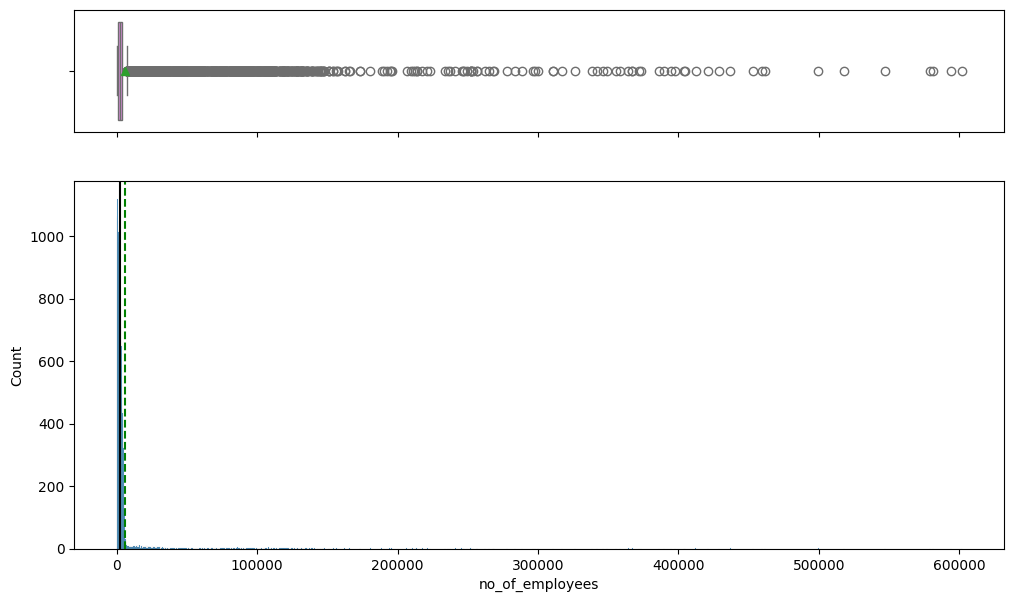

In [216]:
histogram_boxplot(data, "no_of_employees")

- The box is tightly aligned to the left, while the whiskers and outliers extend far to the right.
- This indicates extreme positive skewness—a small number of companies have massive employee counts.
- Several outlier are beyond the upper whisker, indicating negative values.


**yr_of_estab**

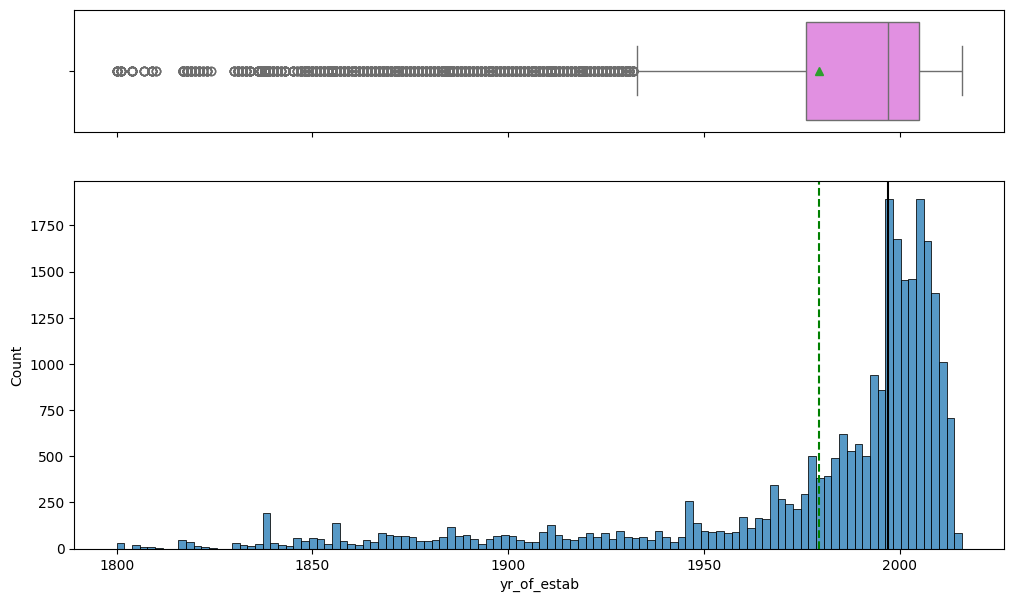

In [217]:
histogram_boxplot(data, "yr_of_estab")

- Graph shows a heavily right skewed data, indicating that most of companies are established around 1980 to 2010 year

**prevailing_wage**

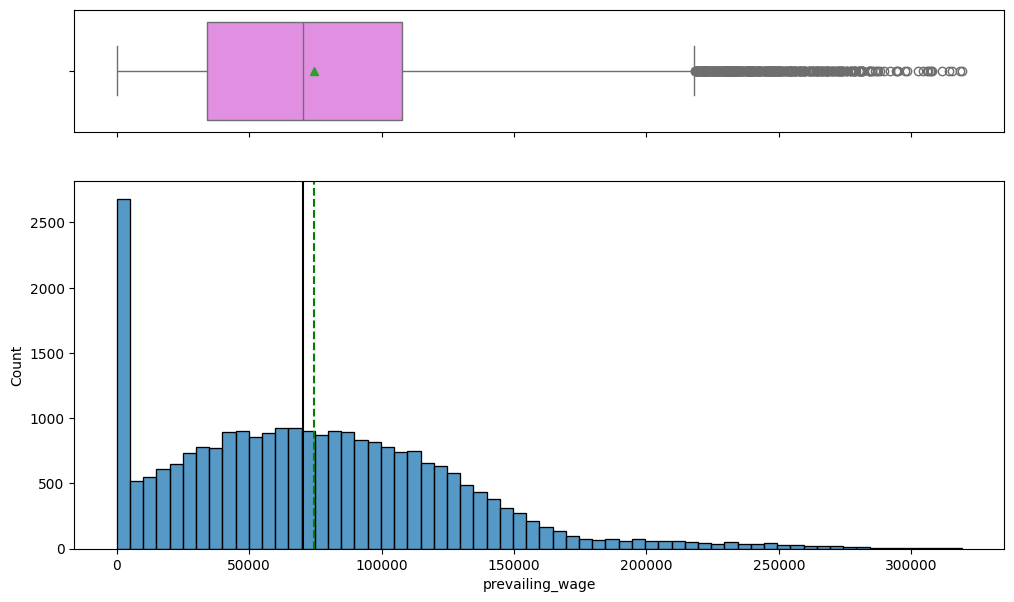

In [218]:
histogram_boxplot(data, "prevailing_wage")

- The graph shows right skewed data, representing that most of the prevailing wages of other employees in same field are in moderate range.

In [219]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

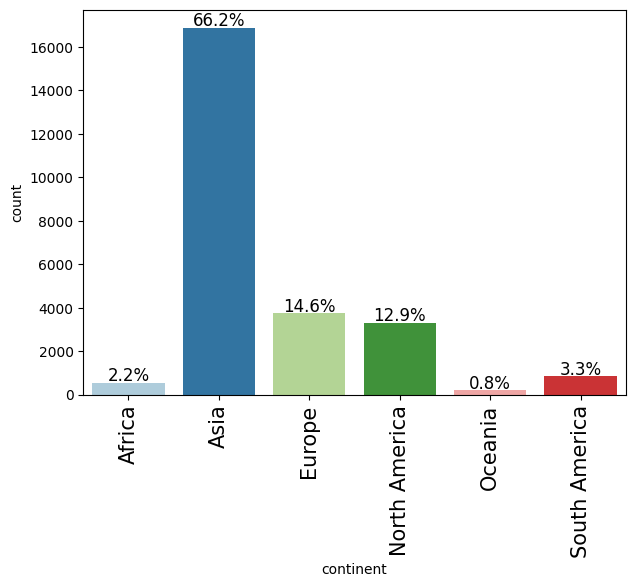

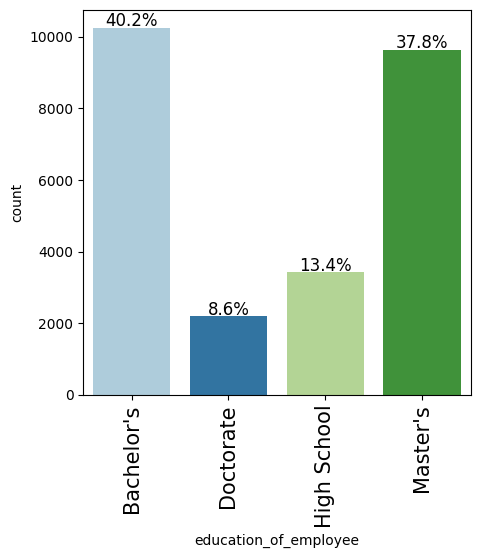

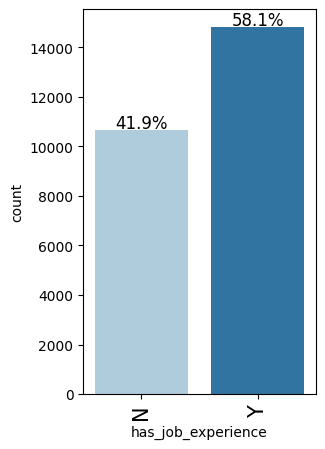

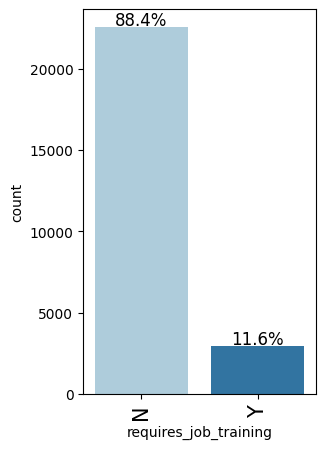

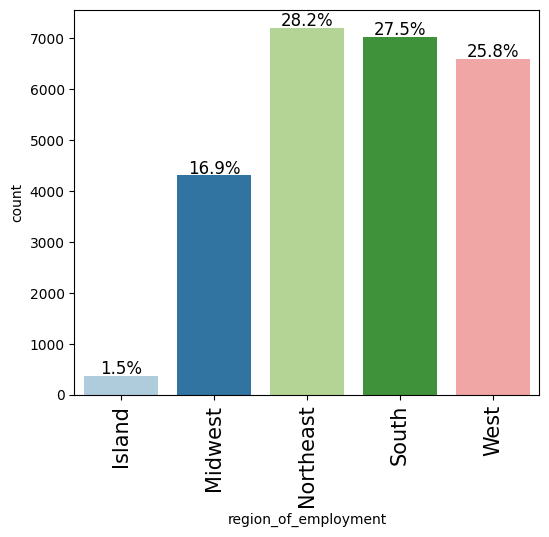

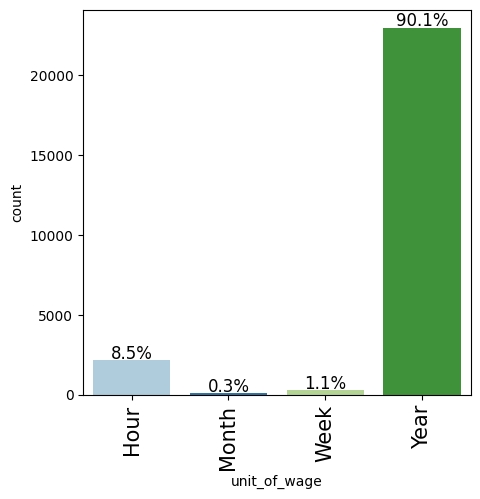

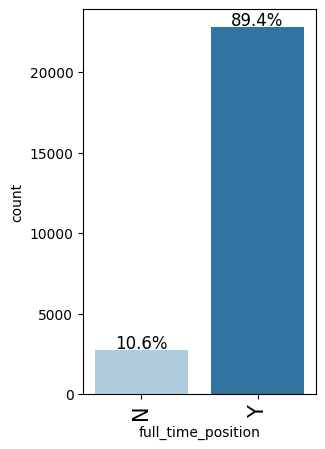

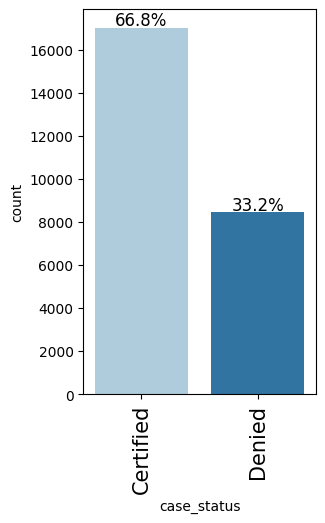

In [220]:
## 1. Observing the continent categorical variable
labeled_barplot(data, "continent", perc=True)
## 2. Observing the education_of_employee categorical variable
labeled_barplot(data, "education_of_employee", perc=True)
## 3. Observing the has_job_experience categorical variable
labeled_barplot(data, "has_job_experience", perc=True)
## 4. Observing the requires_job_training categorical variable
labeled_barplot(data, "requires_job_training", perc=True)
## 5. Observing the region_of_employment categorical variable
labeled_barplot(data, "region_of_employment", perc=True)
## 6. Observing the unit_of_wage categorical variable
labeled_barplot(data, "unit_of_wage", perc=True)
## 7. Observing the full_time_position categorical variable
labeled_barplot(data, "full_time_position", perc=True)
## 8. Observing the case_status categorical variable
labeled_barplot(data, "case_status", perc=True)

- Asians are the most applied people when compared with other countries by 66.2%
- Majority of the applicants have Bachelor's and Master's degree ie., around 40%.
- 58% of applicants have no prior job experience.
- 88.4% of applicants say they dont need a on job training
- Most of the applicants are interested to work and get placed in Northeast, South and West regions
- Employees get paid on yearly basis
- Majority of them i.e., around 90% are full time employeed.
- Around 67% of the applicant visa's are certified or accepted and 33% are denied.

## Bivariate Analysis

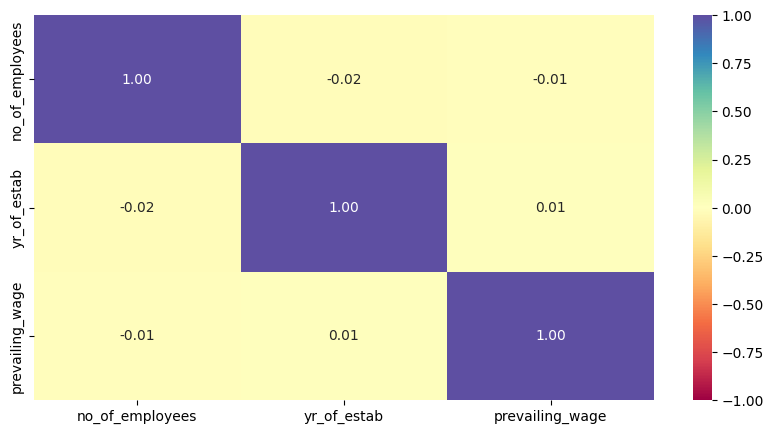

In [221]:
cols_list = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(10, 5))
sns.heatmap(
    data[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

- No strong linear correlations exist between any of the three variables
- This states that changes in one variable do not predict or explain changes in another.


**Let's check the distribution of our target variable i.e Product_Store_Sales_Total with the numeric columns**

### Boxplot Function: Categorical vs Numerical




<Axes: xlabel='no_of_employees', ylabel='prevailing_wage'>

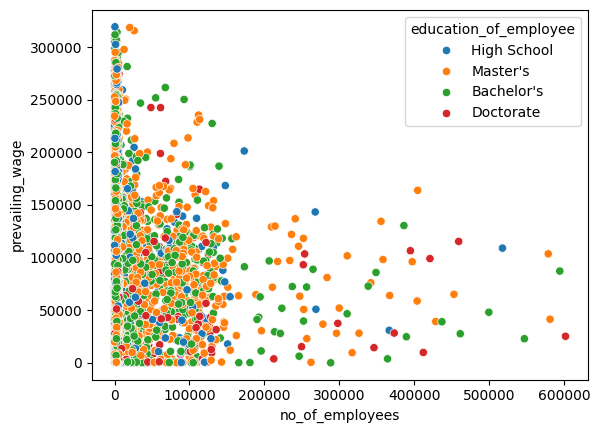

In [222]:
sns.scatterplot(x='no_of_employees', y='prevailing_wage',hue='education_of_employee', data=data)

<Axes: xlabel='yr_of_estab', ylabel='prevailing_wage'>

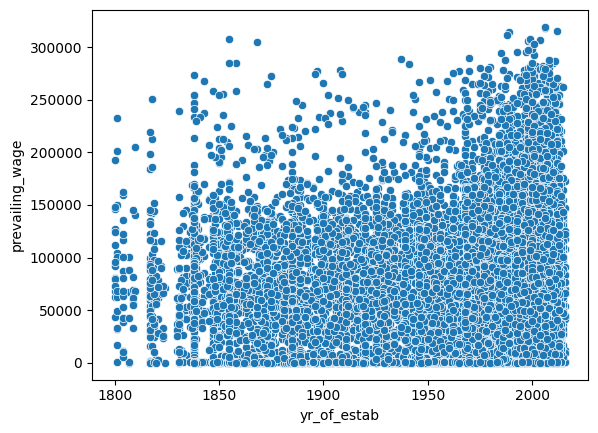

In [223]:
sns.scatterplot(x='yr_of_estab', y='prevailing_wage', data=data)

<Axes: xlabel='no_of_employees', ylabel='prevailing_wage'>

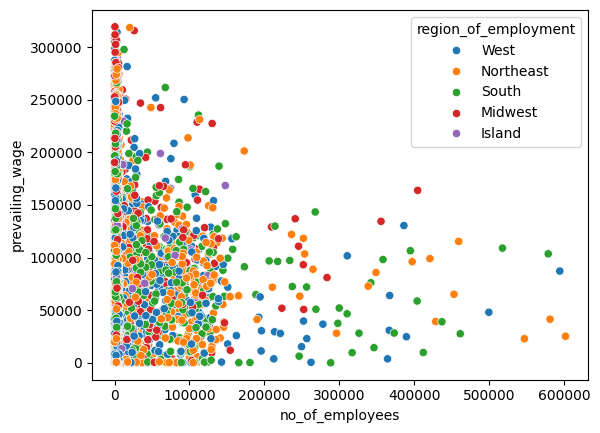

In [224]:
sns.scatterplot(x='no_of_employees', y='prevailing_wage', hue='region_of_employment', data=data)

In [225]:
# Countplot

def plot_categorical_distribution(df, feature, target='case_status'):

    """
    Plots a countplot of a categorical feature against target variable
    and adds count + percentage labels on each bar.

    Parameters:
    df: DataFrame
    feature: str, categorical feature to plot
    target: str, binary target variable (default = 'case_status')
    """
    plt.figure(figsize=(10,6))
    ax = sns.countplot(x=feature, hue=target, data=df, palette='Set2')

    # Compute total counts for percentage calculation
    total_counts = df[feature].value_counts()
    group_counts = df.groupby(feature)[target].value_counts().unstack().fillna(0)

    for container in ax.containers:
        for bar in container:
            height = bar.get_height()
            bar_x = bar.get_x() + bar.get_width() / 2
            feature_val = bar.get_label()
            total = sum(total_counts)
            percent = f'{(height / total * 100):.1f}%'
            ax.text(bar_x, height, f'{height}\n({percent})',
                    ha='center', va='bottom', fontsize=9)

    plt.title(f'Distribution of {feature} by {target}')
    plt.ylabel('Number of Applicants')
    plt.xlabel(feature.replace('_', ' ').title())
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

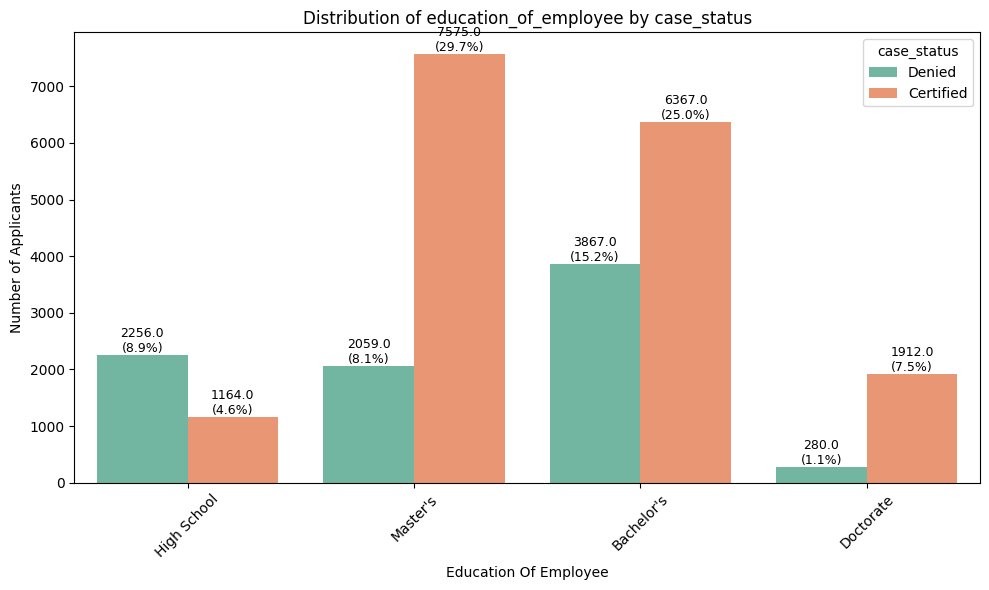

In [226]:
#education_of_employee vs case_status
plot_categorical_distribution(data,'education_of_employee','case_status')

- Master's and bachelor's degree applicants are mostly certified. And amongst denied applicants, most of them are with bachelor's degree.

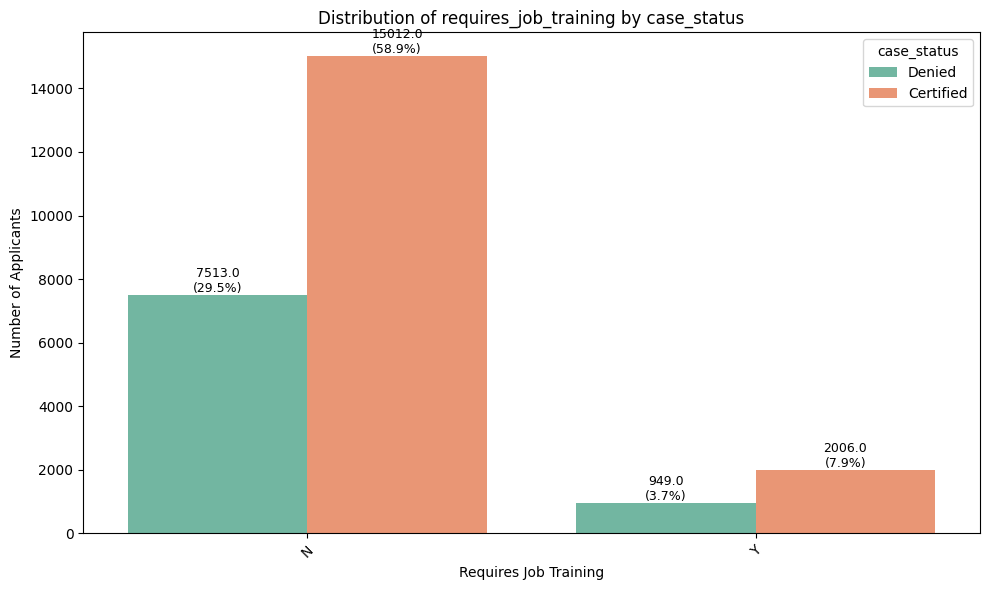

In [227]:
# requires_job_training vs case_status
plot_categorical_distribution(data,'requires_job_training','case_status')

- Most of the denied applicants marked that on-job-training is not needed.

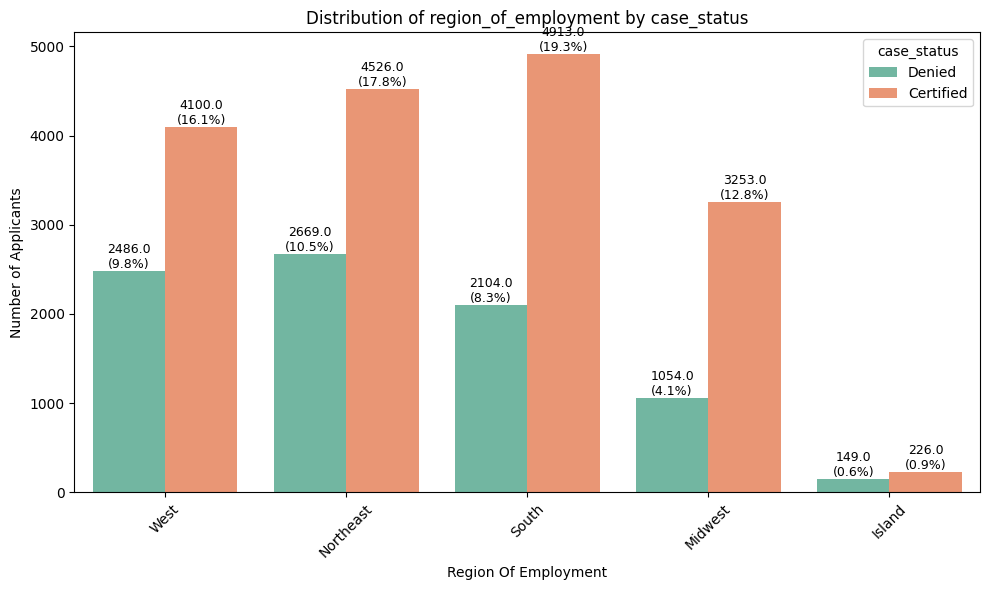

In [228]:
# region_of_employment vs case_status
plot_categorical_distribution(data,'region_of_employment','case_status')

- Most of the certified applicants work in South and Northeast while Island Northeast region see the most number of visa denials.
- Least denials are seen in Island region

## Outliers check

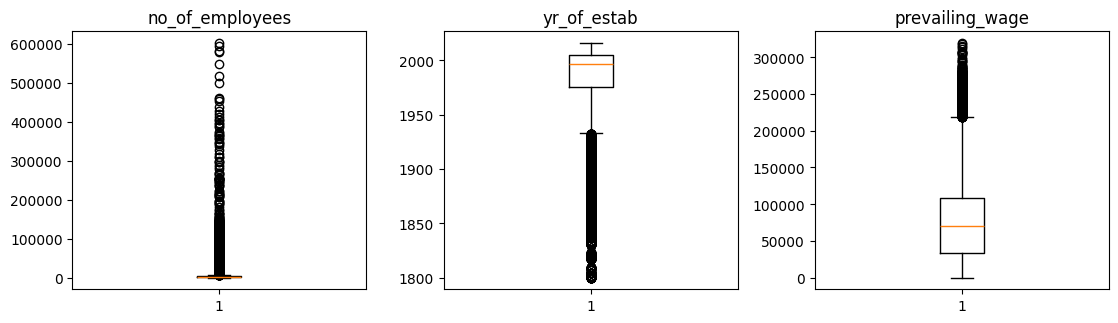

In [229]:
# outlier detection using boxplot
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

**Observations**

- There are quite a few outliers in the data.
- However, we will not treat them as they are proper values.

## Data Preparation for modeling

- We want to forecast the case_status.
- Before we proceed to build a model, we'll have to encode categorical features and drop the unnecessary columns
- We'll split the data into train and test to be able to evaluate the model that we build on the train data.

In [230]:
data.shape

(25480, 11)

In [232]:
data.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,High School,N,N,14513,2007,West,592.203,Hour,Y,Denied
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.650,Year,Y,Certified
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.860,Year,Y,Denied
3,Asia,Bachelor's,N,N,98,1897,West,83434.030,Year,Y,Denied
4,Africa,Master's,Y,N,1082,2005,South,149907.390,Year,Y,Certified


In [239]:
# Defining X & Y variabless features
X = data.drop("case_status", axis=1)
y = data["case_status"]

# Encoding the target variable
y = y.map({'Certified': 1, 'Denied': 0})

In [240]:
# Splitting data into training, validation and test sets:
# first we split data into 2 parts, say temporary and test

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

# then we split the temporary set into train and validation

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=1, stratify=y_temp
)
print(X_train.shape, X_val.shape, X_test.shape)

(15288, 10) (5096, 10) (5096, 10)


In [241]:
# Creating dummy variables for categorical variables
X_train = pd.get_dummies(data=X_train, drop_first=True)
X_val = pd.get_dummies(data=X_val, drop_first=True)
X_test = pd.get_dummies(data=X_test, drop_first=True)

# Model Building

### Model evaluation criterion

### We will be using Recall as a metric for our model performance because here there can be two types of problems
1. Applicants case_status can be denied
2. Applicants case_status can be approved - this is needed to be studied. As our model need to identify applicants who are worthy of approval based on the other dependent variables.

- Metrics like recall and precision will then help assess how well we are finding truly qualifying applicants.
- A high recall for ‘approved’ means we are catching most valid visa candidates — essential for reducing false denials.
- A high precision for ‘approved’ ensures we are not approving those who actually shouldn’t be.

### Initial Model Building

In [242]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))

results = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models
score = []
# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation Performance:" "\n")
for name, model in models:
    scoring = "recall"
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  # Setting number of splits equal to 5
    cv_result = cross_val_score(
        estimator=model, X=X_train, y=y_train, scoring=scoring, cv=kfold
    )
    results.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean() * 100))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train, y_train)
    scores = recall_score(y_val, model.predict(X_val))
    score.append(scores)
    print("{}: {}".format(name, scores))


Cross-Validation Performance:

Bagging: 77.7179236043095
Random forest: 84.30950048971596
GBM: 87.48285994123408
Adaboost: 88.87365328109696
Xgboost: 85.6611165523996
dtree: 73.7806072477963

Validation Performance:

Bagging: 0.7705640423031728
Random forest: 0.8301997649823737
GBM: 0.8742655699177438
Adaboost: 0.8807285546415982
Xgboost: 0.8522326674500588
dtree: 0.745005875440658


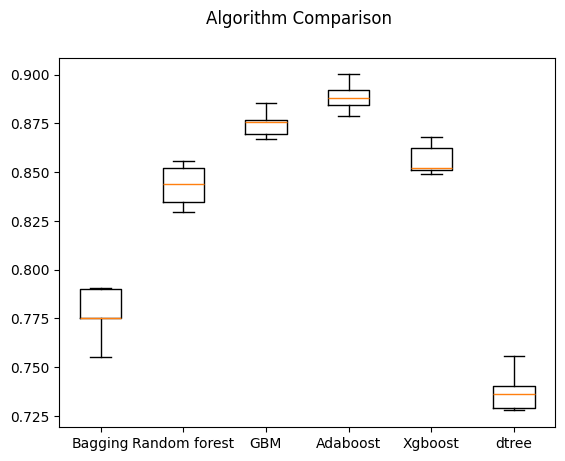

In [243]:
# Plotting boxplots for CV scores of all models defined above
fig = plt.figure()

fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)

plt.boxplot(results)
ax.set_xticklabels(names)

plt.show()

- We can see that the Adaboost is giving the highest cross-validated recall followed by GBM & XG Boost.
- We will tune the best two models i.e. Adaboost & GBM and see if the performance improves.

## Hyperparameter Tuning

**We will tune Adaboost and GBM models using GridSearchCV and RandomizedSearchCV. We will also compare the performance and time taken by these two methods - grid search and randomized search.**

**First let's create two functions to calculate different metrics and confusion matrix, so that we don't have to use the same code repeatedly for each model.**

In [244]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": acc,
            "Recall": recall,
            "Precision": precision,
            "F1": f1,
        },
        index=[0],
    )

    return df_perf

In [245]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

## 1.Adaboost - GridSearchCV

In [248]:
# Base model: Decision Tree
base_model = DecisionTreeClassifier(random_state=1)

# AdaBoost classifier with base estimator
model = AdaBoostClassifier(estimator=base_model, random_state=1)

# Parameter grid for base estimator inside AdaBoost
param_grid = {
    "estimator__criterion": ["gini", "entropy"],
    "estimator__max_depth": [3, 4, 5, None],
    "estimator__min_samples_split": [2, 4, 7, 10, 15],
}

# Scoring function
scorer = metrics.make_scorer(metrics.recall_score)

# GridSearchCV
grid_cv = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scorer, cv=5)

# Fit the model
grid_cv.fit(X_train, y_train)

# Output best parameters and score
print("Best Parameters:{} \nScore: {}".format(grid_cv.best_params_, grid_cv.best_score_))

Best Parameters:{'estimator__criterion': 'gini', 'estimator__max_depth': None, 'estimator__min_samples_split': 4} 
Score: 0.8716944172380019


In [249]:
# Best base estimator with tuned parameters
dtree_tuned = DecisionTreeClassifier(
    random_state=1, criterion="gini", max_depth=None, min_samples_split=2)

# AdaBoost model with the tuned decision tree as base estimator
adaboost_tuned = AdaBoostClassifier(estimator=dtree_tuned, random_state=1)

# Fit AdaBoost model on training data
adaboost_tuned.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(random_state=1),
                   random_state=1)

AdaBoost - Training performance:
   Accuracy  Recall  Precision    F1
0     1.000   1.000      1.000 1.000
AdaBoost - Validation performance:
   Accuracy  Recall  Precision    F1
0     0.665   0.744      0.752 0.748


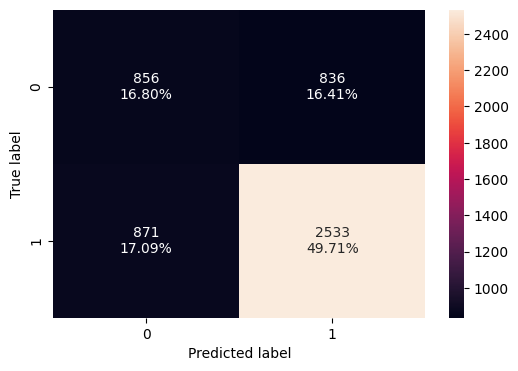

In [250]:
# Calculating different metrics on training set for AdaBoost
adaboost_grid_train = model_performance_classification_sklearn(
    adaboost_tuned, X_train, y_train)
print("AdaBoost - Training performance:")
print(adaboost_grid_train)

# Calculating different metrics on validation set for AdaBoost
adaboost_grid_val = model_performance_classification_sklearn(
    adaboost_tuned, X_val, y_val)
print("AdaBoost - Validation performance:")
print(adaboost_grid_val)

# Creating confusion matrix on validation set
confusion_matrix_sklearn(adaboost_tuned, X_val, y_val)

- Accuracy is average in test data when compared with train data.
- Recall is good by 74% and precision is also good by 75% when compared to training data of 100%. This suggests Adaboost is learning well.

## 2.Adaboost - RandomizedSearchCV

In [251]:
# Base estimator
base_model = DecisionTreeClassifier(random_state=1)

# AdaBoost classifier using updated keyword 'estimator'
model = AdaBoostClassifier(estimator=base_model, random_state=1)

# Parameter grid for randomized search (tuning the base decision tree)
param_grid = {
    "estimator__criterion": ["gini", "entropy"],
    "estimator__max_depth": [3, 4, 5, None],
    "estimator__min_samples_split": [2, 4, 7, 10, 15],
}

# Scoring function — recall
scorer = metrics.make_scorer(metrics.recall_score)

# RandomizedSearchCV setup
randomized_cv = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=20,
    scoring=scorer,
    cv=5,
    random_state=1,
)

# Fit model on training data
randomized_cv.fit(X_train, y_train)

# Print best parameters and cross-validated recall score
print(
    "Best parameters are {} with CV score={}:".format(
        randomized_cv.best_params_, randomized_cv.best_score_
    )
)

Best parameters are {'estimator__min_samples_split': 15, 'estimator__max_depth': 4, 'estimator__criterion': 'entropy'} with CV score=0.8688540646425074:


In [252]:
# Best base estimator from RandomizedSearchCV
dtree_tuned2 = DecisionTreeClassifier(
    random_state=1, criterion="entropy", max_depth=None, min_samples_split=2)

# AdaBoost model using the tuned decision tree
adaboost_final = AdaBoostClassifier(estimator=dtree_tuned2, random_state=1)

# Fit AdaBoost model on training data
adaboost_final.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(criterion='entropy',
                                                    random_state=1),
                   random_state=1)

Training performance:
   Accuracy  Recall  Precision    F1
0     1.000   1.000      1.000 1.000
Validation performance:
   Accuracy  Recall  Precision    F1
0     0.662   0.744      0.749 0.746


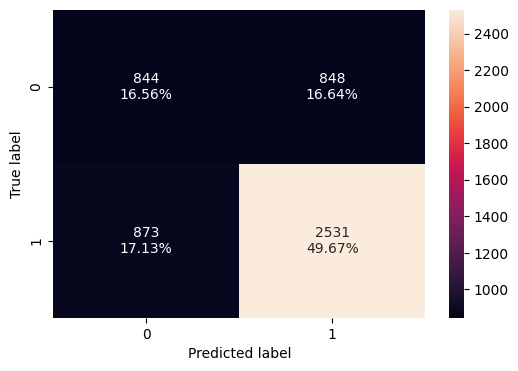

In [265]:
# Evaluate AdaBoost model performance on training set
adaboost_random_train = model_performance_classification_sklearn(
    adaboost_final, X_train, y_train)
print("Training performance:")
print(adaboost_random_train)

# Evaluate AdaBoost model performance on validation set
adaboost_random_val = model_performance_classification_sklearn(
    adaboost_final, X_val, y_val)
print("Validation performance:")
print(adaboost_random_val)

# Generate confusion matrix on validation set
confusion_matrix_sklearn(adaboost_final, X_val, y_val)

- Data is overfitting in training data.
- Confusion matrix still suggests numbers are very close — so about half of the truly approved applicants are being correctly classified, and the other half are slipping.  

## 3.GBM - GridSearchCV

In [256]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn import metrics

# Defining the model
model = GradientBoostingClassifier(random_state=1)

# Parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [50, 100],
    'learning_rate': [0.1],
    'subsample': [0.8, 1.0], # Added a comma here
    'max_depth': [2, 3],
    'min_samples_split': [2],
    'min_samples_leaf': [1]
}

# Scoring metric (Recall)
scorer = metrics.make_scorer(metrics.recall_score)

# Setting up GridSearchCV
grid_cv = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring=scorer,
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fitting GridSearchCV
grid_cv.fit(X_train, y_train)

# Outputting best parameters and score
print("Best parameters are {} with CV score={}:".format(grid_cv.best_params_, grid_cv.best_score_))

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters are {'learning_rate': 0.1, 'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50, 'subsample': 0.8} with CV score=0.9069539666993144:


In [257]:
from sklearn.ensemble import GradientBoostingClassifier

# Building GBM model with best parameters
gbm_tuned = GradientBoostingClassifier(
    random_state=1,
    n_estimators=50,
    learning_rate=0.01,
    subsample=0.8,
    max_depth=1,
    min_samples_split=2,
    min_samples_leaf=1
)

# Fit the model on training data
gbm_tuned.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.01, max_depth=1, n_estimators=50,
                           random_state=1, subsample=0.8)

Training performance:
   Accuracy  Recall  Precision    F1
0     0.668   1.000      0.668 0.801
Validation performance:
   Accuracy  Recall  Precision    F1
0     0.668   1.000      0.668 0.801


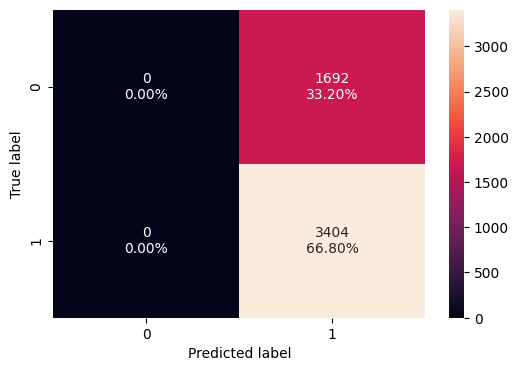

In [258]:
# Calculating different metrics on train set for GBM
gbm_grid_train = model_performance_classification_sklearn(
    gbm_tuned, X_train, y_train)
print("Training performance:")
print(gbm_grid_train)

# Calculating different metrics on validation set for GBM
gbm_grid_val = model_performance_classification_sklearn(
    gbm_tuned, X_val, y_val)
print("Validation performance:")
print(gbm_grid_val)

# Creating confusion matrix for GBM
confusion_matrix_sklearn(gbm_tuned, X_val, y_val)

- Recall is 1.000: It’s correctly capturing all true positives.
- But Precision drops: Because it’s predicting positives even when many are false.

## 4.GBM - RandomizedSearchCV

In [259]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn import metrics
import numpy as np

# Defining the GBM model
model = GradientBoostingClassifier(random_state=1)

# Parameter grid for RandomizedSearchCV
param_grid = {
    'n_estimators': np.arange(50, 100),
    'learning_rate': [0.1],
    'subsample': [0.8,1.0],
    'max_depth': np.arange(2,3),
    'min_samples_split': [2],
    'min_samples_leaf': [1]
}

# Scoring metric — recall
scorer = metrics.make_scorer(metrics.recall_score)

# RandomizedSearchCV setup
gbm_tuned = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=50,
    scoring=scorer,
    cv=5,
    random_state=1,
    n_jobs=-1,
    verbose=1
)

# Fitting to training data
gbm_tuned.fit(X_train, y_train)

# Displaying best parameters and score
print("Best parameters are {} with CV score={}:".format(
    gbm_tuned.best_params_, gbm_tuned.best_score_))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters are {'subsample': 0.8, 'n_estimators': np.int64(51), 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': np.int64(2), 'learning_rate': 0.1} with CV score=0.9068560235063664:


In [260]:
from sklearn.ensemble import GradientBoostingClassifier

# Build GBM model with best parameters from RandomizedSearchCV
gbm_tuned2 = GradientBoostingClassifier(
    random_state=1,
    n_estimators=50,
    learning_rate=0.01,
    subsample=0.9,
    max_depth=1,
    min_samples_split=2,  # Adjust based on your randomized search output
    min_samples_leaf=1    # Same here
)

# Fit the model on training data
gbm_tuned2.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.01, max_depth=1, n_estimators=50,
                           random_state=1, subsample=0.9)

Training performance:
   Accuracy  Recall  Precision    F1
0     0.668   1.000      0.668 0.801
Validation performance:
   Accuracy  Recall  Precision    F1
0     0.668   1.000      0.668 0.801


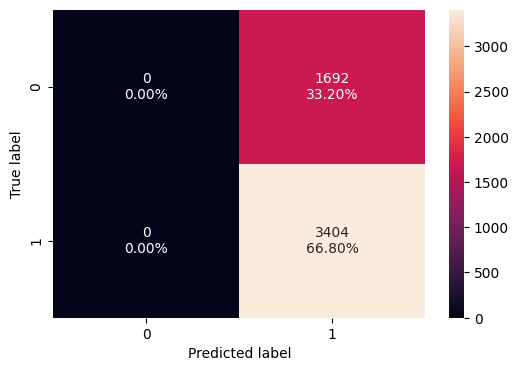

In [261]:
# Calculating different metrics on training set for GBM
gbm_random_train = model_performance_classification_sklearn(
    gbm_tuned2, X_train, y_train)
print("Training performance:")
print(gbm_random_train)

# Calculating different metrics on validation set for GBM
gbm_random_val = model_performance_classification_sklearn(
    gbm_tuned2, X_val, y_val)
print("Validation performance:")
print(gbm_random_val)

# Creating confusion matrix for GBM
confusion_matrix_sklearn(gbm_tuned2, X_val, y_val)

- model here shows perfect recall (1.000) but at the cost of a big false positive rate, which explains the modest precision (0.668) and the zero true negatives shown in the matrix.

# Comparing models from GridsearchCV and RandomisedsearchCV

In [269]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        adaboost_grid_train.T,
        adaboost_random_train.T,
        gbm_grid_train.T,
        gbm_random_train.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Addaboost Tuned with Grid search",
    "Adaboost Tuned with Random search",
    "GBM Tuned with Grid search",
    "GBM Tuned with Random Search",
]
print("\nTraining performance comparison:")
print(models_train_comp_df)

# Validation performance comparison

models_val_comp_df = pd.concat(
    [
        adaboost_grid_val.T,
        adaboost_random_val.T,
        gbm_grid_val.T,
        gbm_random_val.T,
    ],
    axis=1,
)
models_val_comp_df.columns = [
    "Adadboost Tuned with Grid search",
    "Adaboost Tuned with Random search",
    "GBM Tuned with Grid search",
    "GBM Tuned with Random Search",
]
print("\nValidation performance comparison:")
print(models_val_comp_df)


Training performance comparison:
           Addaboost Tuned with Grid search  \
Accuracy                              1.000   
Recall                                1.000   
Precision                             1.000   
F1                                    1.000   

           Adaboost Tuned with Random search  GBM Tuned with Grid search  \
Accuracy                               1.000                       0.668   
Recall                                 1.000                       1.000   
Precision                              1.000                       0.668   
F1                                     1.000                       0.801   

           GBM Tuned with Random Search  
Accuracy                          0.668  
Recall                            1.000  
Precision                         0.668  
F1                                0.801  

Validation performance comparison:
           Adadboost Tuned with Grid search  \
Accuracy                              0.665   
Recall   

- Adaboost models (both tuned by Grid and Random search) show perfect performance on training—this hints at possible overfitting.
- GBM models had lower accuracy and precision but still managed perfect recall, meaning they captured all true positives.
- Identical scores across search strategies (Grid vs Random) for each model type show consistent optimization effectiveness.

Key Insights
- Grid Search vs Random Search yielded similar outcomes across models, so Random Search might be preferable when time/resources are constrained.
- Adaboost might be overfitting—perfect training metrics but lower generalization.
- GBM, despite lower precision, maintains excellent recall and stable validation performance.

In [270]:
# Let's check the performance on test set
Model_test = model_performance_classification_sklearn(xgb_tuned1, X_test, y_test)
Model_test


,Accuracy,Recall,Precision,F1
0,0.668,1.000,0.668,0.801


#### Feature Importance


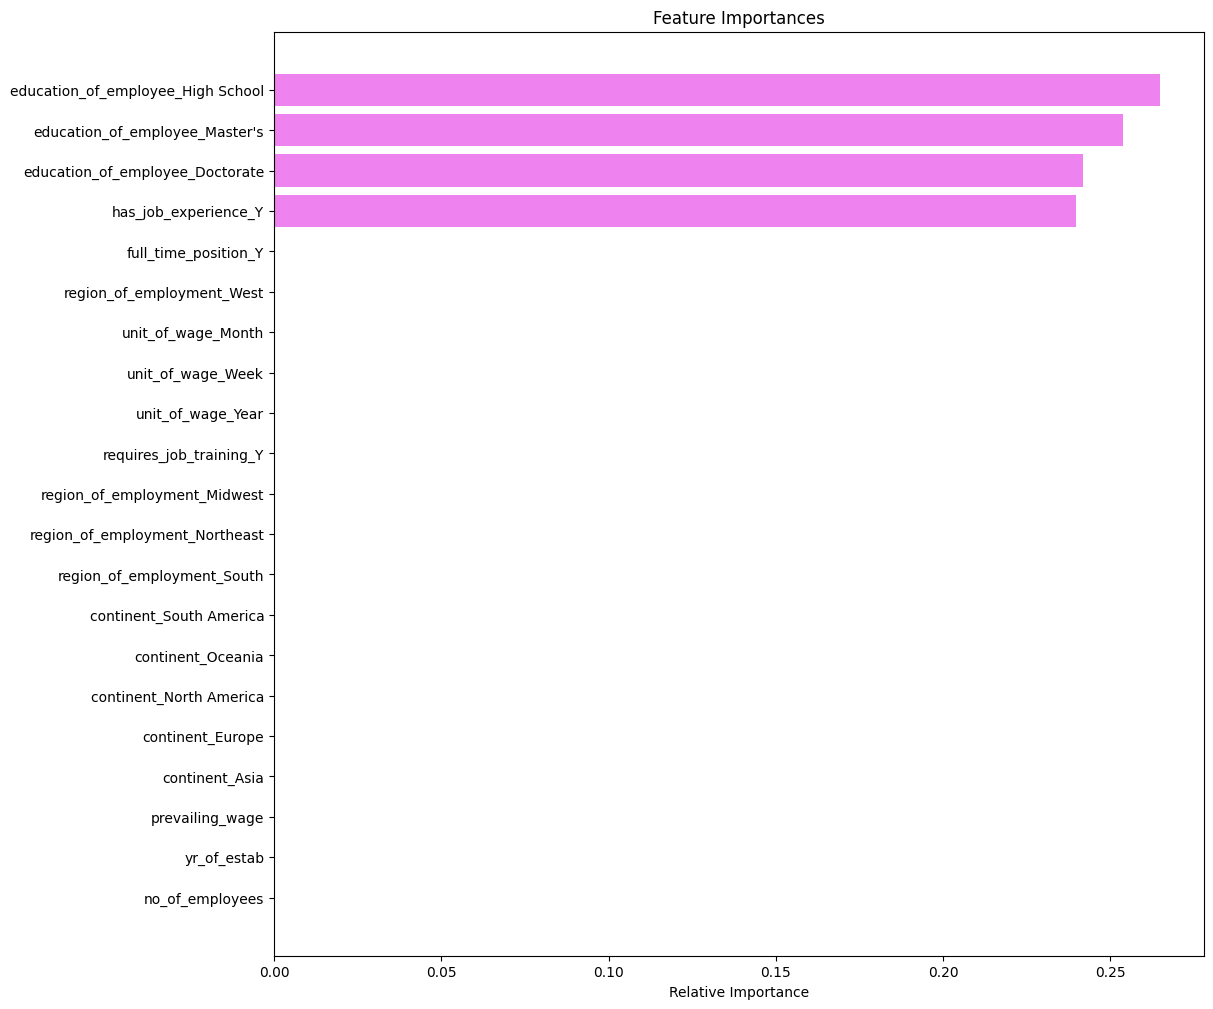

In [271]:
feature_names = X_train.columns
importances = xgb_tuned1.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

- Education and has job experience are the two most important variables as these variable play an important role in taking/returning credit.

# Conclusion and Insights

- GBM tuned via either method (Grid or Random Search) is your most balanced performer—excellent recall, strong F1, and stable across train/validation.
- Education and has_job_experience are the two most important variables as these variable play an important role in taking/returning credit.
- hence these points should be considered while selecting applicants.